In [1]:
import sys, os, torch, random
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader
from omegaconf import OmegaConf

warnings = __import__('warnings')
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../../..'))

In [2]:
from DL.models.rotate_net import RotateNet
from DL.models.cascade_net import CascadeNet
from DL.trainers.model_trainer import ModelTrainer
from DL.trainers.rotatenet_trainer import RotateNetTrainer
from DL.data.rotated_cyrillic_dataset import RotatedCyrillicDataset
from DL.loggers.experiment_logger import ExperimentLogger
from DL.visualization.visualizer import ExperimentVisualizer

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42) # Фиксируем сид

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [5]:
experiment_name = "cascade_rotatenet_flatten_220kb"
logger = ExperimentLogger(experiment_name, base_dir=".")
visualizer = ExperimentVisualizer(logger)

In [6]:
train_dataset = RotatedCyrillicDataset(60000, 42, max_angle=150)
test_dataset = RotatedCyrillicDataset(15000, 999, max_angle=150)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Предобучение RotateNet ~212 KB

In [7]:
# === ЭТАП 1: Обучение тяжелого RotateNet (~212 KB) ===
print("=== ЭТАП 1: Обучение RotateNet (Flatten) ===")
conf_rot = OmegaConf.load('../../../DL/configs/rotatenet/rotatenet_flatten.json')
rotatenet = RotateNet(OmegaConf.to_container(conf_rot)).to(device)

opt_rot = torch.optim.Adam(rotatenet.parameters(), lr=1e-3)
rot_trainer = RotateNetTrainer(
    model=rotatenet, optimizer=opt_rot, criterion=nn.MSELoss(),
    device=device, logger=logger, model_name="RotateNet_Flatten"
)
rot_trainer.fit(train_loader, epochs=10)

=== ЭТАП 1: Обучение RotateNet (Flatten) ===


Epoch 1/10[25.6s] - Train Loss: 0.3995


Epoch 2/10[26.9s] - Train Loss: 0.1995


Epoch 3/10[27.6s] - Train Loss: 0.2772


Epoch 4/10[27.5s] - Train Loss: 0.1307


...

Epoch 7/10[27.5s] - Train Loss: 0.0849


Epoch 8/10[27.3s] - Train Loss: 0.0760


Epoch 9/10[28.1s] - Train Loss: 0.0716


Epoch 10/10[27.2s] - Train Loss: 0.0684


{'train_loss': [0.39951473452250164,
  0.19948010172843933,
  0.27720994138717653,
  0.13070491886933644,
  0.1050272854646047,
  0.12302458973725637,
  0.08490080878138542,
  0.07598075204690298,
  0.07155303661028545,
  0.06841709357698758]}

# End-to-End обучение моделей (RotateNet + LeNet)

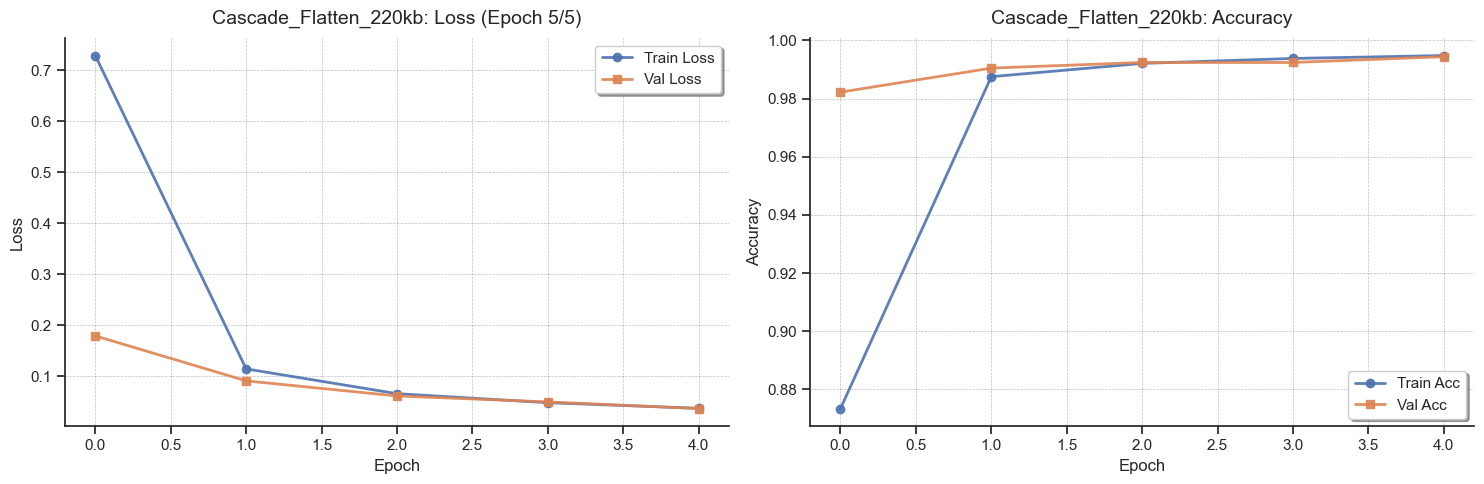

{'train_loss': [0.7287220493634542,
  0.1147556682507197,
  0.06613678968548775,
  0.04852350339690844,
  0.03747548112273216],
 'train_acc': [0.8734,
  0.9875166666666667,
  0.9920833333333333,
  0.9937833333333334,
  0.9947833333333334],
 'train_bg_loss': [0.530762896009783,
  7.092452049255371e-06,
  0.0,
  1.9254498183727265e-05,
  1.2131169438362122e-05],
 'val_loss': [0.17940396620432536,
  0.09127456677357355,
  0.06161218127210935,
  0.04999832873940468,
  0.03690494374235471],
 'val_acc': [0.9822, 0.9904666666666667, 0.9924, 0.9924, 0.9944]}

In [8]:
# === ЭТАП 2: Обучение Каскада ===
print("\n=== ЭТАП 2: Обучение 8KB CascadeNet ===")
conf_lenet = OmegaConf.load('../../../DL/configs/lenet/lenet_8kb.json')
conf_lenet.num_classes = len(train_dataset.char_to_idx)

cascade_model = CascadeNet(OmegaConf.to_container(conf_lenet), rotatenet).to(device)
optimizer_cascade = torch.optim.Adam(cascade_model.classifier.parameters(), lr=1e-3)

trainer_cascade = ModelTrainer(
    model=cascade_model, optimizer=optimizer_cascade, criterion=nn.CrossEntropyLoss(), device=device,
    use_background_loss=True, bg_loss_alpha=15.0, bg_loss_n=2,
    logger=logger, visualizer=visualizer, model_name="Cascade_Flatten_220kb"
)

trainer_cascade.fit(train_loader, test_loader, epochs=5)

# Визуализация

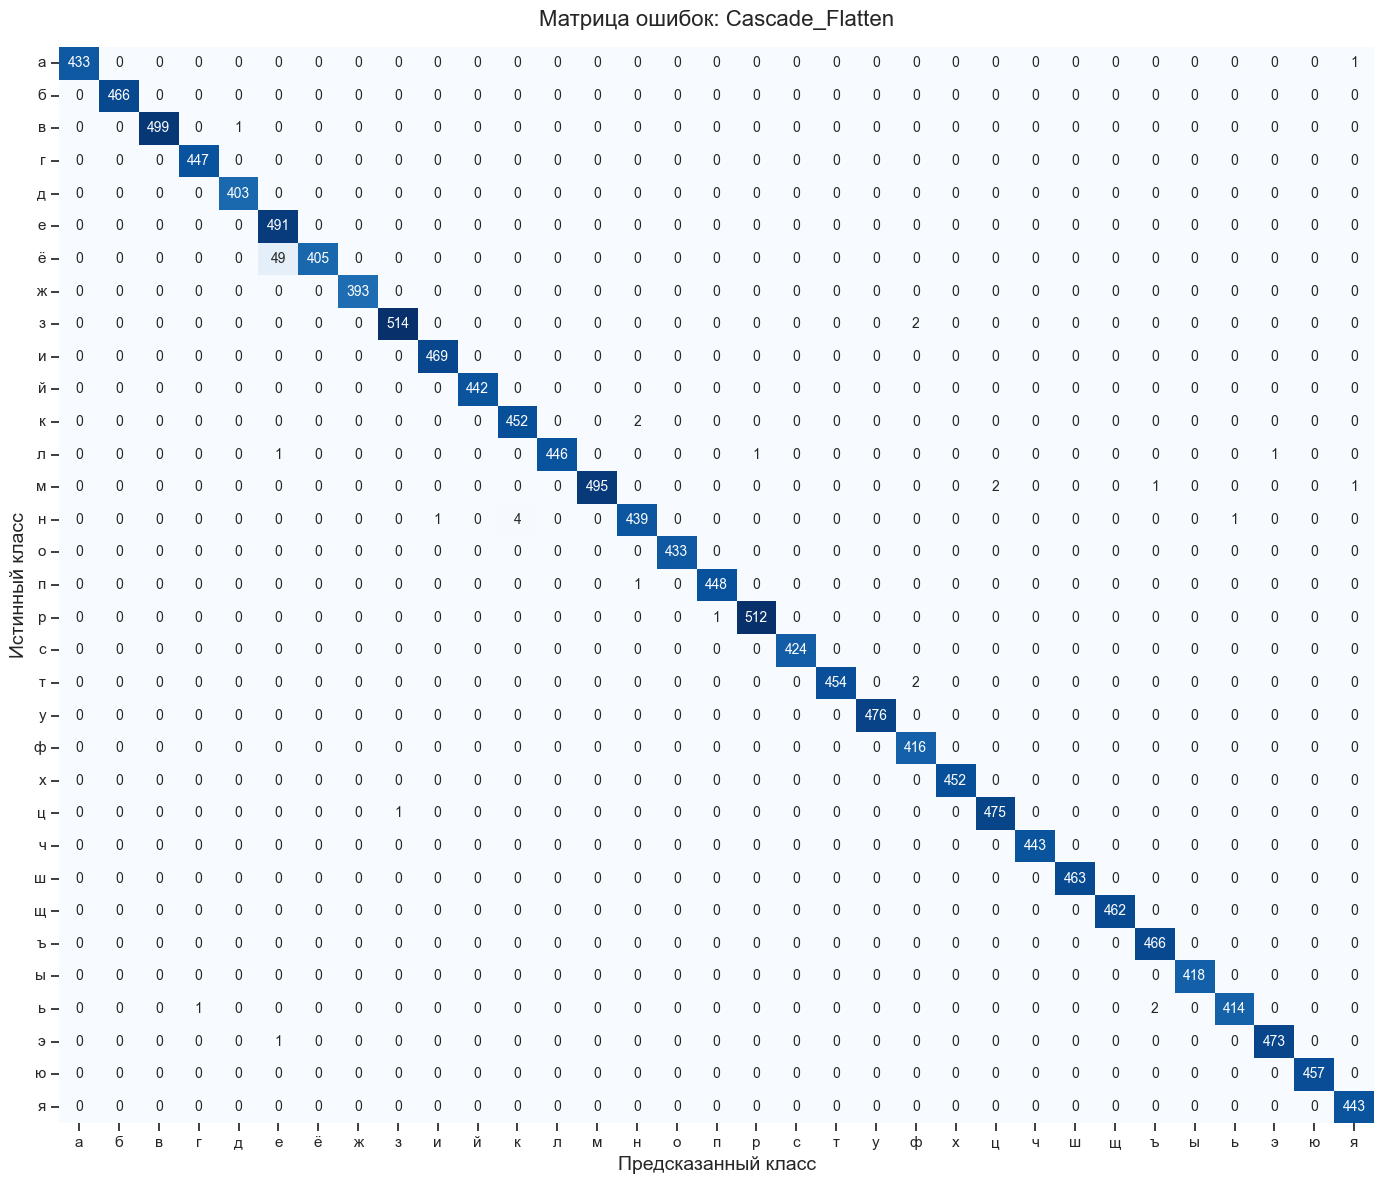

In [9]:
visualizer.plot_confusion_matrix(cascade_model, test_loader, test_dataset, device, model_name="Cascade_Flatten")

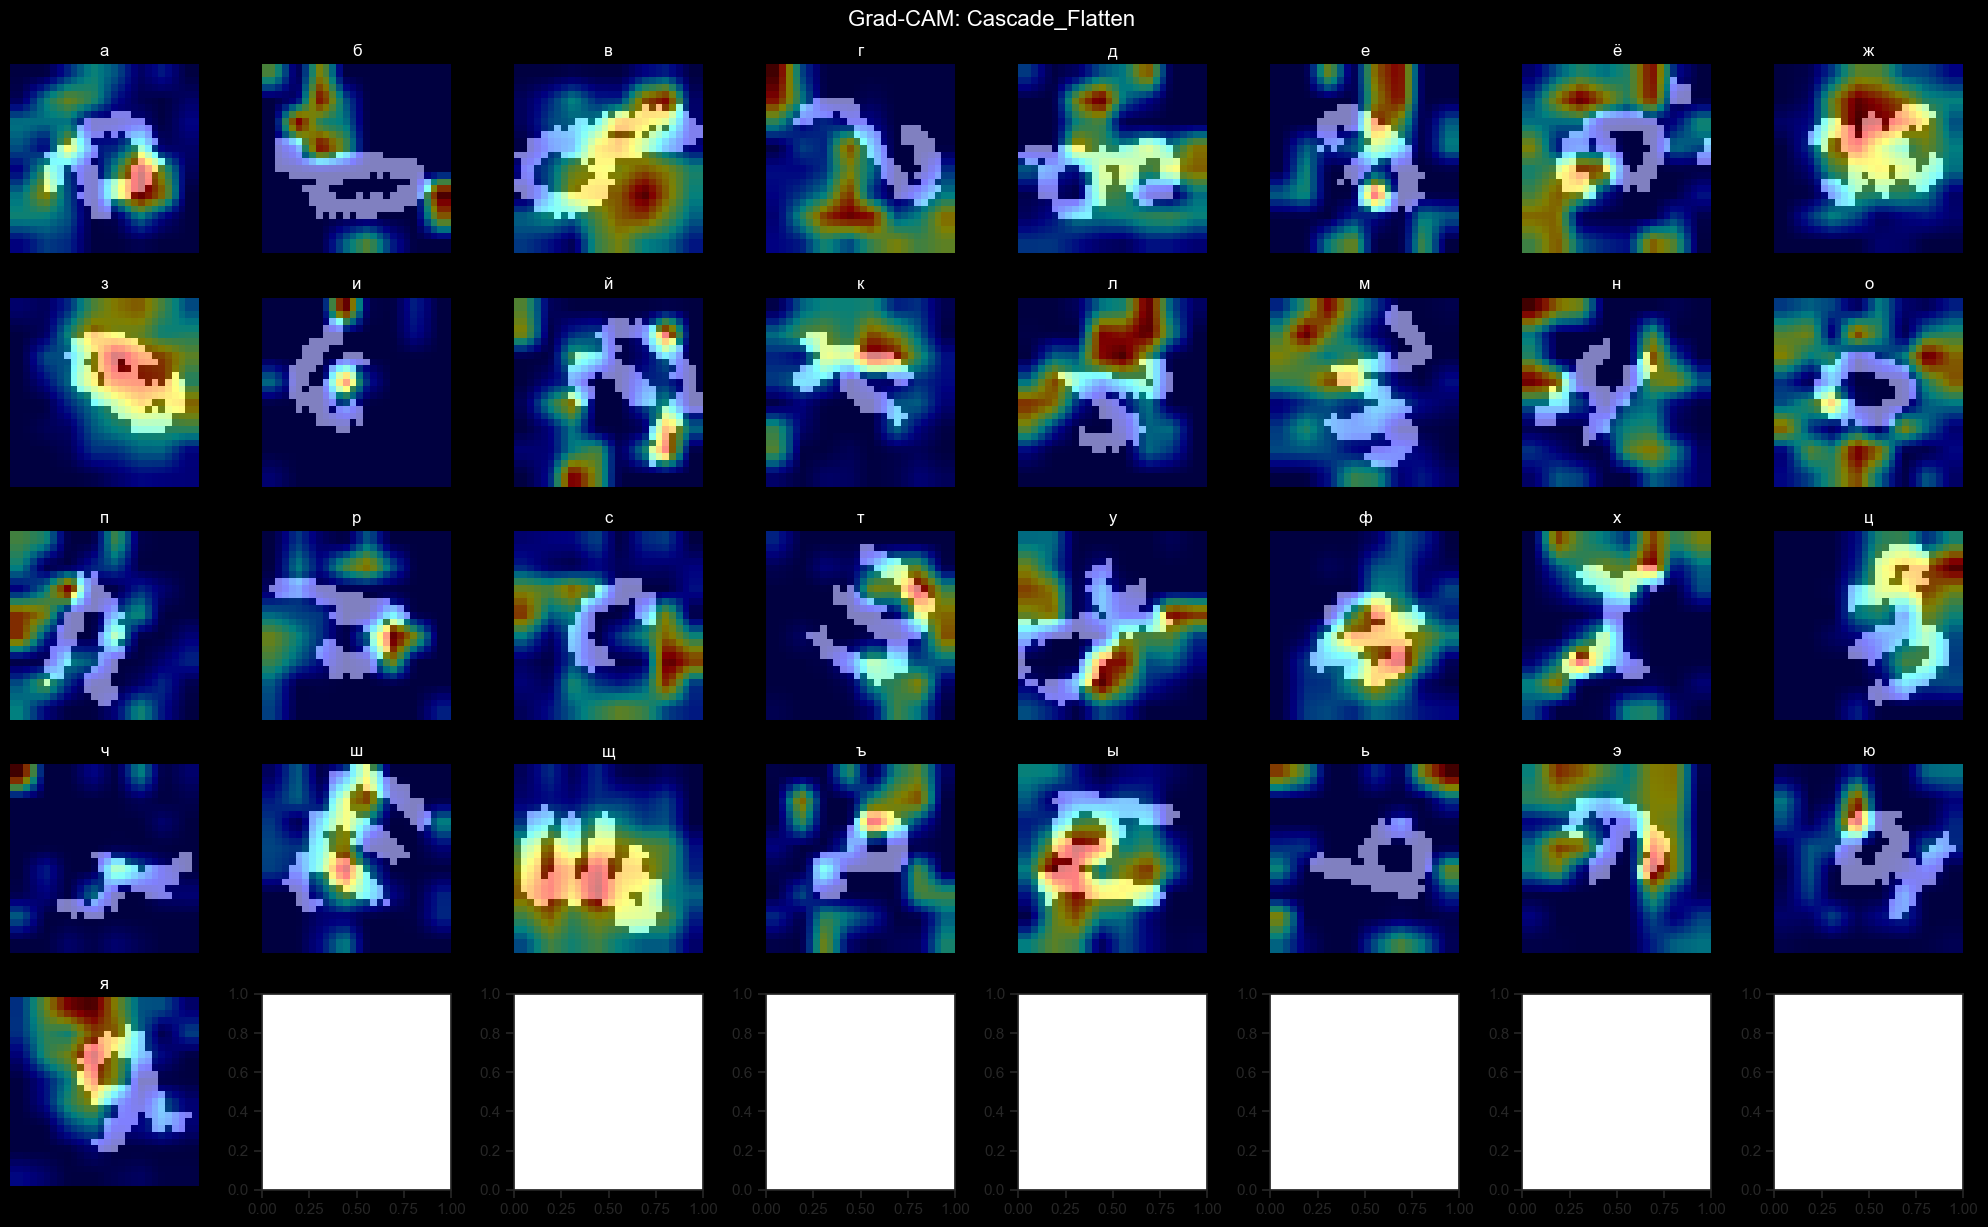

<Figure size 640x480 with 0 Axes>

In [10]:
visualizer.plot_gradcam(cascade_model, test_dataset, device, model_name="Cascade_Flatten")